# Titanic — предсказание выживаемости

Решил попробовать CatBoost на классике. Датасет маленький, но интересный — здесь важнее думать головой, чем подбирать сложные модели.

Результат на паблик лидерборде: **0.77751**

Основная идея простая: пол + класс + семья + возраст. Никакой магии, только нормальный feature engineering и аккуратная настройка.

## Импорты

In [35]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

PLOT_COLOR   = '#4C72B0'
ACCENT_COLOR = '#DD8452'
RANDOM_STATE = 42

## Данные

In [36]:
train_raw = pd.read_csv('train.csv')
test_raw  = pd.read_csv('test.csv')

print(f"train: {train_raw.shape}, test: {test_raw.shape}")
train_raw.head()

train: (891, 12), test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## EDA

Сначала смотрю на пропуски — `Age` пропущен у ~20% пассажиров, `Cabin` почти весь пустой. CatBoost умеет работать с NaN сам, поэтому `Age` оставлю как есть. `Cabin` пока не трогаю.

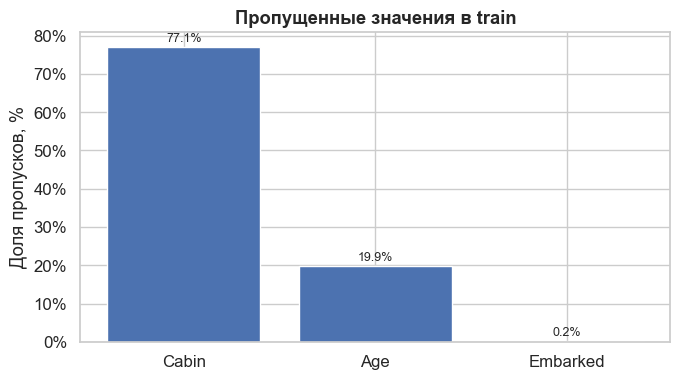

In [37]:
# Пропуски
missing = train_raw.isnull().mean().mul(100).sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(missing.index, missing.values, color=PLOT_COLOR, edgecolor='white')
ax.set_ylabel('Доля пропусков, %')
ax.set_title('Пропущенные значения в train', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(bars, missing.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

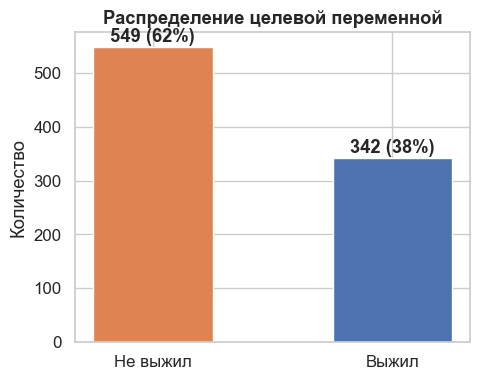

In [38]:
# Баланс классов
fig, ax = plt.subplots(figsize=(5, 4))
vc = train_raw['Survived'].value_counts()
bars = ax.bar(['Не выжил', 'Выжил'], vc.values,
              color=[ACCENT_COLOR, PLOT_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f'{val} ({val/len(train_raw)*100:.0f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Распределение целевой переменной', fontweight='bold')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

# Классы чуть несбалансированы, но не критично — 62/38

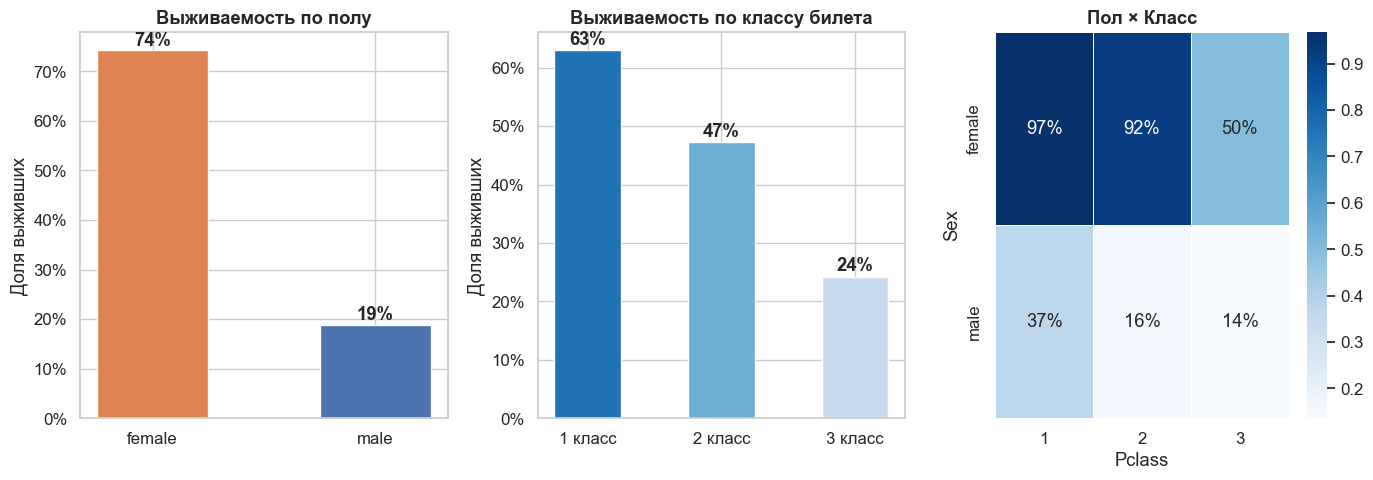

In [39]:
# Пол и класс — самые очевидные предикторы
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# по полу
survival_sex = train_raw.groupby('Sex')['Survived'].mean().reset_index()
axes[0].bar(survival_sex['Sex'], survival_sex['Survived'],
            color=[ACCENT_COLOR, PLOT_COLOR], edgecolor='white', width=0.5)
axes[0].set_title('Выживаемость по полу', fontweight='bold')
axes[0].set_ylabel('Доля выживших')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, row in survival_sex.iterrows():
    axes[0].text(i, row['Survived'] + 0.01, f"{row['Survived']:.0%}",
                 ha='center', fontweight='bold')

# по классу
survival_cls = train_raw.groupby('Pclass')['Survived'].mean().reset_index()
bars = axes[1].bar(['1 класс', '2 класс', '3 класс'], survival_cls['Survived'],
                   color=sns.color_palette('Blues_r', 3), edgecolor='white', width=0.5)
axes[1].set_title('Выживаемость по классу билета', fontweight='bold')
axes[1].set_ylabel('Доля выживших')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, val in zip(bars, survival_cls['Survived']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f'{val:.0%}', ha='center', fontweight='bold')

# тепловая карта пол × класс
pivot = train_raw.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
sns.heatmap(pivot, ax=axes[2], annot=True, fmt='.0%', cmap='Blues', linewidths=0.5)
axes[2].set_title('Пол × Класс', fontweight='bold')

plt.tight_layout()
plt.show()

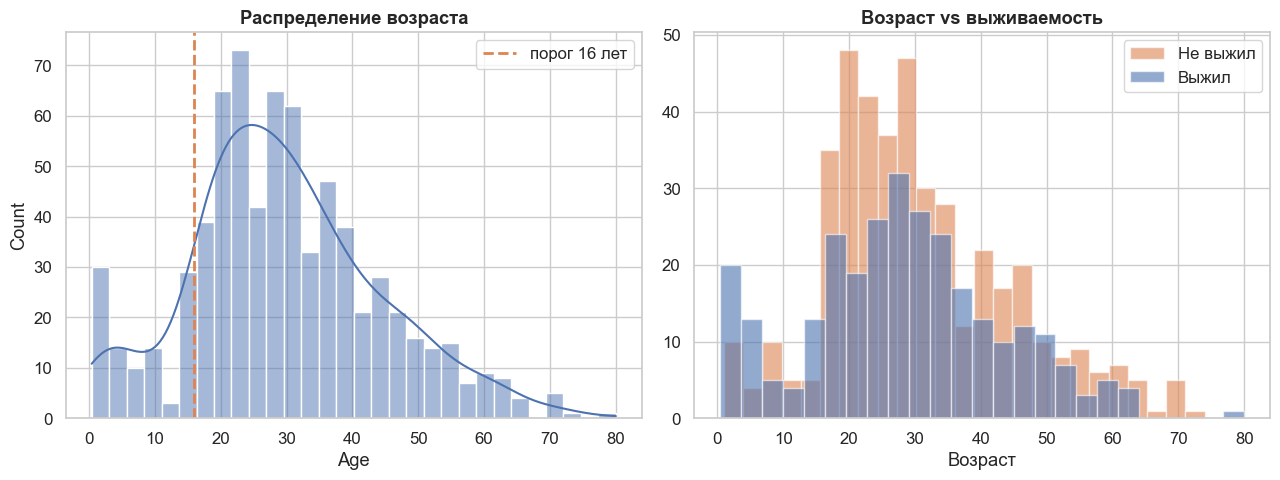

Дети (< 16 лет):  59% выживших
Взрослые (>= 16): 38% выживших


In [40]:
# Распределение возраста
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(train_raw['Age'].dropna(), bins=30, ax=axes[0],
             color=PLOT_COLOR, edgecolor='white', kde=True)
axes[0].axvline(16, color=ACCENT_COLOR, linestyle='--', linewidth=2, label='порог 16 лет')
axes[0].set_title('Распределение возраста', fontweight='bold')
axes[0].legend()

for survived, label, color in [(0, 'Не выжил', ACCENT_COLOR), (1, 'Выжил', PLOT_COLOR)]:
    data = train_raw[train_raw['Survived'] == survived]['Age'].dropna()
    axes[1].hist(data, bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
axes[1].set_title('Возраст vs выживаемость', fontweight='bold')
axes[1].legend()
axes[1].set_xlabel('Возраст')

plt.tight_layout()
plt.show()

print(f"Дети (< 16 лет):  {train_raw[train_raw['Age'] < 16]['Survived'].mean():.0%} выживших")
print(f"Взрослые (>= 16): {train_raw[train_raw['Age'] >= 16]['Survived'].mean():.0%} выживших")

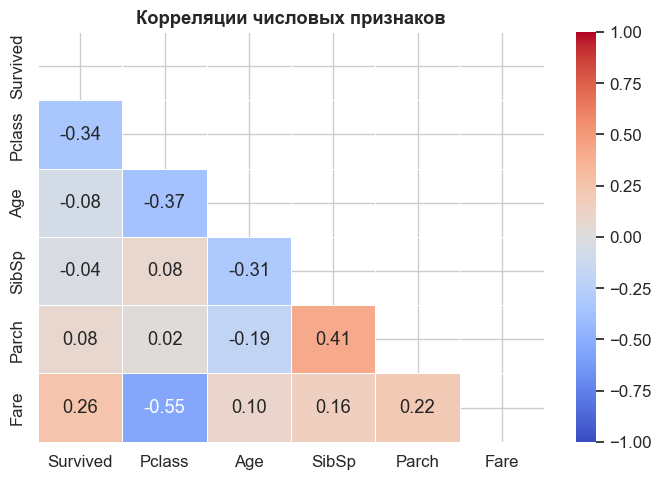

In [41]:
# Корреляционная матрица числовых признаков
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train_raw[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Корреляции числовых признаков', fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Engineering

Два новых признака:

- **`Col`** = `SibSp + Parch` — общий размер семьи. Отдельно эти два столбца несут меньше смысла, вместе — понятнее: одиночки выживают хуже семей среднего размера, но большие семьи тоже теряются.
- **`IsChild`** — флаг `Age < 16`. На графике выше видно, что дети выживали заметно чаще. Это прямое отражение эвакуационного протокола.

Bольше ничего не добавляю — датасет маленький и легко переобучиться на шум.

In [42]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Col']     = df['SibSp'] + df['Parch']
    df['IsChild'] = (df['Age'] < 16).astype(int)
    return df

train = engineer_features(train_raw)
test  = engineer_features(test_raw)

print(train[['SibSp', 'Parch', 'Col', 'Age', 'IsChild']].head(8))

   SibSp  Parch  Col   Age  IsChild
0      1      0    1  22.0        0
1      1      0    1  38.0        0
2      0      0    0  26.0        0
3      1      0    1  35.0        0
4      0      0    0  35.0        0
5      0      0    0   NaN        0
6      0      0    0  54.0        0
7      3      1    4   2.0        1


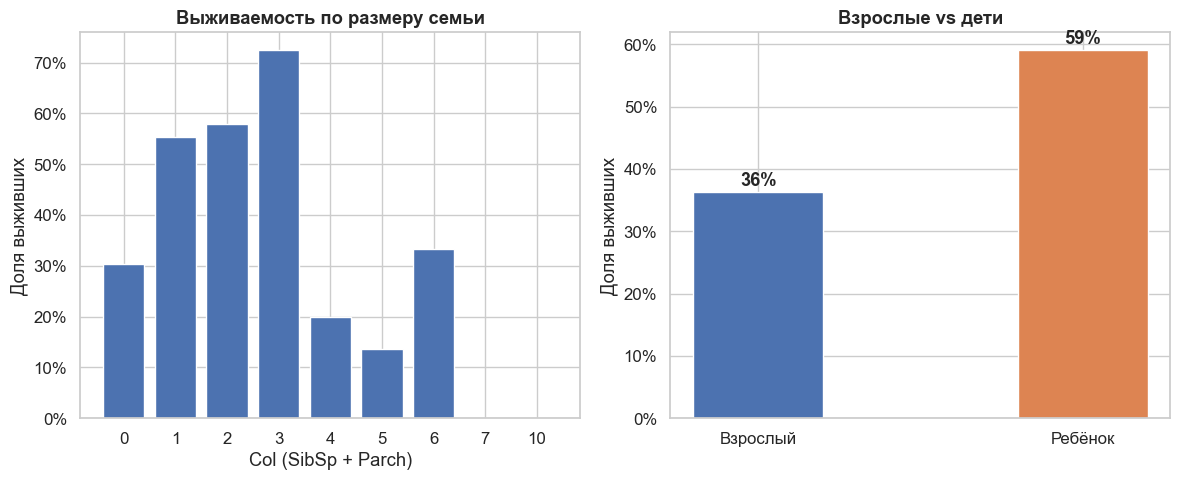

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

col_surv = train.groupby('Col')['Survived'].mean().reset_index()
axes[0].bar(col_surv['Col'].astype(str), col_surv['Survived'],
            color=PLOT_COLOR, edgecolor='white')
axes[0].set_title('Выживаемость по размеру семьи', fontweight='bold')
axes[0].set_xlabel('Col (SibSp + Parch)')
axes[0].set_ylabel('Доля выживших')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

child_surv = train.groupby('IsChild')['Survived'].mean().reset_index()
axes[1].bar(['Взрослый', 'Ребёнок'], child_surv['Survived'],
            color=[PLOT_COLOR, ACCENT_COLOR], edgecolor='white', width=0.4)
axes[1].set_title('Взрослые vs дети', fontweight='bold')
axes[1].set_ylabel('Доля выживших')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, val in enumerate(child_surv['Survived']):
    axes[1].text(i, val + 0.01, f'{val:.0%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Модель

Выбрал CatBoost по нескольким причинам:
- нативно обрабатывает категориальные признаки — `Sex` передаю напрямую без кодирования
- нормально справляется с пропусками в `Age`
- меньше возни с настройкой, чем у XGBoost

Сначала обучаю с базовыми параметрами, потом прогоняю GridSearchCV и переобучаю с лучшими.

In [44]:
FEATURES     = ['Pclass', 'Sex', 'Col', 'Fare', 'Age', 'IsChild']
TARGET       = 'Survived'
CAT_FEATURES = ['Sex']

X = train[FEATURES]
y = train[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

print(f"train: {X_train.shape[0]} | val: {X_val.shape[0]}")

train: 623 | val: 268


In [45]:
model = CatBoostClassifier(
    cat_features  = CAT_FEATURES,
    random_seed   = RANDOM_STATE,
    verbose       = 0,
    eval_metric   = 'Accuracy',
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
)

print("Обучение завершено")

Обучение завершено


## Подбор гиперпараметров

Прогнал GridSearchCV по основным параметрам — `iterations`, `learning_rate`, `depth`. Сетка достаточно широкая, чтобы найти что-то лучше дефолтных значений, но не настолько огромная, чтобы ждать вечность.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid=  {
    'iterations': [300, 500],
    'learning_rate': [0.01, 0.03, 0.05],
    'depth': [3, 5, 10],
}

grid_model = CatBoostClassifier(
    l2_leaf_reg  = 2,
    cat_features = CAT_FEATURES,
    random_seed  = RANDOM_STATE,
    verbose      = 0,
)

grid_search = GridSearchCV(
    estimator  = grid_model,
    param_grid = param_grid,
    cv         = 2,
    scoring    = 'accuracy',
    n_jobs     = -1,
)

grid_search.fit(X_train, y_train)

print(f"Лучшие параметры : {grid_search.best_params_}")
print(f"Лучший CV score  : {grid_search.best_score_:.4f}")

Лучшие параметры : {'depth': 5, 'iterations': 300, 'learning_rate': 0.03}
Лучший CV score  : 0.8363


In [47]:
best_params = grid_search.best_params_

# Переобучаем с лучшими параметрами
model = CatBoostClassifier(
    **best_params,
    l2_leaf_reg  = 2,
    cat_features = CAT_FEATURES,
    random_seed  = RANDOM_STATE,
    verbose      = 0,
    eval_metric  = 'Accuracy',
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
)

print("Модель с зафиксированными параметрами обучена")

Модель с зафиксированными параметрами обучена


## Результаты

In [48]:
y_pred      = model.predict(X_val)
y_pred_prob = model.predict_proba(X_val)[:, 1]

acc     = accuracy_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_prob)

cv_scores = cross_val_score(
    CatBoostClassifier(
        **best_params,
        l2_leaf_reg=2, cat_features=CAT_FEATURES,
        random_seed=RANDOM_STATE, verbose=0
    ),
    X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f"Accuracy (val)       : {acc:.4f}")
print(f"ROC-AUC  (val)       : {roc_auc:.4f}")
print(f"CV Accuracy (5 fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(classification_report(y_val, y_pred, target_names=['Не выжил', 'Выжил']))

Accuracy (val)       : 0.8321
ROC-AUC  (val)       : 0.8804
CV Accuracy (5 fold) : 0.8328 ± 0.0154

              precision    recall  f1-score   support

    Не выжил       0.81      0.94      0.87       157
       Выжил       0.88      0.68      0.77       111

    accuracy                           0.83       268
   macro avg       0.85      0.81      0.82       268
weighted avg       0.84      0.83      0.83       268



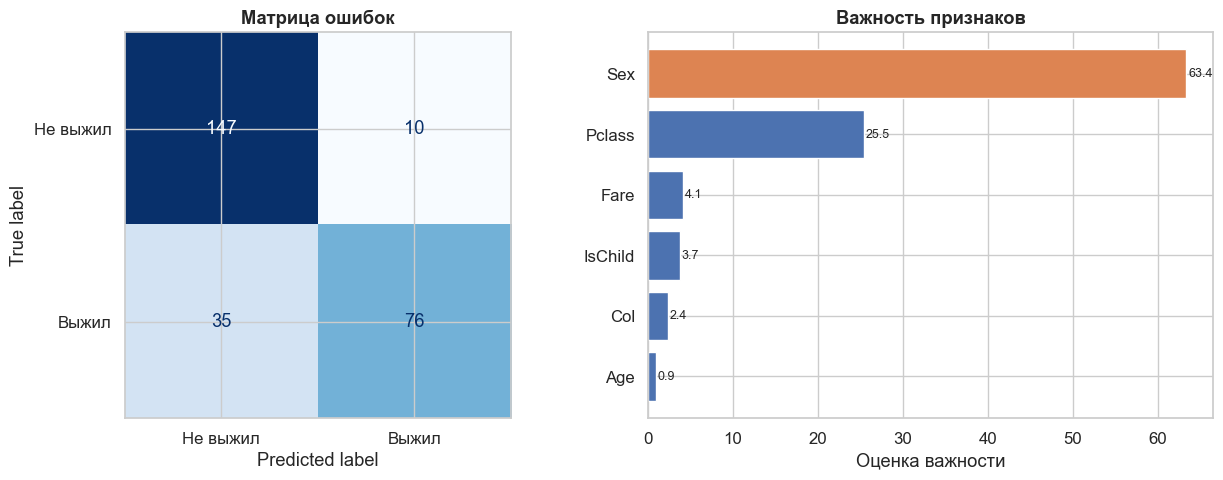

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Не выжил', 'Выжил']).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Матрица ошибок', fontweight='bold')

# Важность признаков
importances = pd.Series(
    model.get_feature_importance(),
    index=FEATURES
).sort_values(ascending=True)

colors = [ACCENT_COLOR if v == importances.max() else PLOT_COLOR for v in importances.values]
axes[1].barh(importances.index, importances.values, color=colors, edgecolor='white')
axes[1].set_title('Важность признаков', fontweight='bold')
axes[1].set_xlabel('Оценка важности')
for i, val in enumerate(importances.values):
    axes[1].text(val + 0.2, i, f'{val:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Пол (`Sex`) ожидаемо выходит на первое место — самый сильный признак. `Fare` и `Age` тоже вносят вклад, `IsChild` меньше, но без него CV чуть хуже.

## Финальная модель и сабмит

Финальную модель обучаем на тех же 70% данных что использовались при обучении, обучение на полном train (100%) на этом датасете даёт переобучение и ухудшает результат на тесте.

In [50]:
# Финальная модель — обучаем на X_train (70%)
final_model = CatBoostClassifier(
    **best_params,
    l2_leaf_reg  = 2,
    cat_features = CAT_FEATURES,
    random_seed  = RANDOM_STATE,
    verbose      = 0,
)
final_model.fit(X_train, y_train)  # 70%, не весь train

X_test      = test[FEATURES]
y_pred_test = final_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived'   : y_pred_test.astype(int)
})
submission.to_csv('submission.csv', index=False)

print(f"submission.csv готов — {submission['Survived'].sum()} выживших из {len(submission)}")
submission.head(10)

submission.csv готов — 129 выживших из 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


## Что можно улучшить

Несколько идей, которые пока не пробовал:

- **Заголовок из имени** — Mr, Mrs, Miss, Master и т.д. `Master` = мальчик, и это напрямую влияет на выживаемость. Довольно просто достать через regex.
- **Палуба из каюты** — первая буква `Cabin` косвенно говорит о расположении на корабле. Пропусков много, но можно хотя бы сделать бинарный флаг «есть каюта / нет».
- **Fare на человека** — групповые билеты делят fare между несколькими пассажирами. `Fare / (Col + 1)` будет честнее.
- **Ансамбль** — CatBoost + LightGBM + логрег дают стабильный небольшой прирост на этом датасете.